# Load Cached AnnData Objects

This notebook is now for working with the cached `.h5ad` files only. It does not convert Seurat `.rds` files and it should not remake AnnData files during normal analysis.

Current cached files:

- Shi 2019 paper QC: `$PROJECT_ROOT/results/python_anndata/shi_2019_paper_qc.h5ad`
- Varela DIV30: `$PROJECT_ROOT/results/python_anndata/varela_div30.h5ad`
- Varela DIV90: `$PROJECT_ROOT/results/python_anndata/varela_div90.h5ad`

If a source Seurat object changes, rebuild the cache with the Slurm template from a login-node terminal:

```bash
cd /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
cp slurm_templates/08_convert_python_anndata.sbatch.template   /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
sbatch /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
```

The Slurm job skips existing current `.h5ad` files unless the template is changed to run with overwrite.

## Analysis Goal And Contract

Main goal: recreate and extend the published Shi/Varela organoid analysis in Python, starting from the cached AnnData objects and using the published findings as the reference point.

Working contract for this notebook:

- Start from cached `.h5ad` files only; do not remake Seurat conversions here.
- Preserve original metadata columns from the Seurat objects.
- Add new harmonized or derived columns with explicit names instead of overwriting originals.
- First reproduce published-facing views: dataset summaries, published labels, UMAPs, and marker patterns.
- Then run Python-native analyses such as QC summaries, marker scoring, clustering, and cross-dataset comparisons.
- Keep exploratory helper functions in the notebook until they are stable.
- Move stable helpers into `python_notebooks/src/mge_organoid_python/` only after the notebook logic is working and useful.

The notebook should remain the analysis narrative. Python modules should hold reusable mechanics once they have stabilized.

## Kernel And Path Setup

Use the `Python (mge-organoid-python)` kernel. This cell adds the repo-local Python package under `python_notebooks/src` so imports work from the notebook without installing the package into site-packages.

In [15]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
if len(cwd.parents) >= 2:
    candidate_roots.append(cwd.parents[1])

for root in candidate_roots:
    src = root / "python_notebooks" / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        repo_root = root
        break
else:
    raise RuntimeError("Could not locate python_notebooks/src from the current notebook directory")

repo_root

PosixPath('/home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline')

In [16]:
import platform
import shutil

import matplotlib.pyplot as plt
import pandas as pd

from mge_organoid_python import (
    cached_h5ad_path,
    default_studies,
    load_cached_anndatas,
    missing_cached_h5ads,
    resolve_project_root,
    validate_source_paths,
)

project_root = resolve_project_root(os.environ.get("PROJECT_ROOT"))
studies = default_studies()
studies_by_id = {study.study_id: study for study in studies}

print("PROJECT_ROOT =", project_root)
for study in studies:
    print(f"{study.study_id}: {cached_h5ad_path(study, project_root=project_root)}")

PROJECT_ROOT = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
shi_2019_paper_qc: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/shi_2019_paper_qc.h5ad
varela_div30: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad
varela_div90: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div90.h5ad


## Runtime Diagnostics

This confirms where the notebook kernel is running. Loading cached `.h5ad` files is allowed on a login node for light checks, especially with `backed="r"`. Do not run Seurat conversion from this notebook.

In [17]:
hostname = platform.node()
print("hostname:", hostname)
print("python:", sys.executable)
print("PROJECT_ROOT:", os.environ.get("PROJECT_ROOT"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("SLURM_JOB_ID:", os.environ.get("SLURM_JOB_ID"))
print("Rscript:", shutil.which("Rscript"))

if hostname.startswith("gl-login"):
    print("NOTE: This kernel is on a login node. Keep work light and use backed='r'.")
else:
    print("NOTE: This kernel is not on a login node.")

hostname: gl3088.arc-ts.umich.edu
python: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/python
PROJECT_ROOT: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
CONDA_DEFAULT_ENV: mge-organoid-python
SLURM_JOB_ID: 50317780
Rscript: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/Rscript
NOTE: This kernel is not on a login node.


## Confirm Inputs And Cached Outputs

The Seurat source path check tells you whether the canonical `.rds` files still exist. The cached output check is the important one for this notebook: all three `.h5ad` files must exist before analysis cells run.

In [18]:
source_missing = validate_source_paths(studies)
if source_missing:
    raise FileNotFoundError(f"Missing Seurat source files: {source_missing}")

cache_missing = missing_cached_h5ads(studies, project_root=project_root)
if cache_missing:
    raise FileNotFoundError(
        "Missing cached H5AD files: {}. Rebuild them with "
        "slurm_templates/08_convert_python_anndata.sbatch.template before running analysis.".format(cache_missing)
    )

cache_table = pd.DataFrame(
    [
        {
            "study_id": study.study_id,
            "label": study.label,
            "h5ad_path": str(cached_h5ad_path(study, project_root=project_root)),
            "size_gb": round(cached_h5ad_path(study, project_root=project_root).stat().st_size / 1024**3, 2),
        }
        for study in studies
    ]
)
cache_table

,study_id,label,h5ad_path,size_gb
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.99
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,4.48
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.57


## Load Cached AnnData

The default is `backed="r"`, which opens each `.h5ad` read-only and avoids loading the full expression matrix into memory. This is the normal mode for inspection, metadata work, and UMAP plotting.

Use `backed=None` only when you intentionally need full in-memory AnnData for downstream methods that require modifying or densifying data.

In [19]:
adatas, reports = load_cached_anndatas(studies, project_root=project_root, backed="r")
reports_df = pd.DataFrame([report.as_dict() for report in reports])
reports_df

,study_id,label,h5ad_path,n_obs,n_vars,has_umap,n_obs_columns,n_var_columns
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,56136,21191,True,14,1
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,90631,18082,True,12,1
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,22338,18082,True,14,1


## Analysis Roadmap

Initial notebook-first analysis sections:

1. AnnData inventory: shapes, layers, `.obs`, `.var`, `.obsm`, and available metadata.
2. Metadata harmonization: identify equivalent columns across Shi, DIV30, and DIV90 without overwriting originals.
3. QC and composition summaries: cells per dataset, sample, condition, and cluster label.
4. UMAP reproduction: original embeddings colored by published labels and key metadata.
5. Marker validation: known MGE/organoid marker genes on UMAPs, dot plots, and grouped summaries.
6. Python-native reanalysis: PCA/neighbors/Leiden/UMAP when needed, compared back to published labels.
7. Cross-dataset comparison: Shi vs Varela DIV30 vs Varela DIV90 using shared labels and marker programs.

Start by inspecting what metadata columns actually exist in each AnnData object before assuming a label name.

## AnnData Inventory Helpers

These helper functions stay in the notebook for now. Their job is to summarize what is actually present in each cached AnnData object before we harmonize metadata or reproduce published figures.

In [20]:
def adata_inventory(adatas):
    rows = []
    for study_id, adata in adatas.items():
        rows.append(
            {
                "study_id": study_id,
                "n_obs": adata.n_obs,
                "n_vars": adata.n_vars,
                "n_obs_columns": adata.obs.shape[1],
                "n_var_columns": adata.var.shape[1],
                "layers": ", ".join(adata.layers.keys()) if adata.layers else "",
                "obsm": ", ".join(adata.obsm.keys()) if adata.obsm else "",
                "has_X_umap": "X_umap" in adata.obsm,
            }
        )
    return pd.DataFrame(rows)


def obs_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.obs.columns})
    rows = []
    for column in all_columns:
        row = {"obs_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.obs.columns
        rows.append(row)
    return pd.DataFrame(rows)


def var_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.var.columns})
    rows = []
    for column in all_columns:
        row = {"var_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.var.columns
        rows.append(row)
    return pd.DataFrame(rows)


def categorical_obs_summary(adata, columns=None, max_unique=30):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        series = adata.obs[column]
        nunique = int(series.nunique(dropna=True))
        if nunique <= max_unique or str(series.dtype) == "category":
            counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
            rows.append(
                {
                    "column": column,
                    "dtype": str(series.dtype),
                    "n_unique": nunique,
                    "top_values": "; ".join(f"{idx}: {value}" for idx, value in counts.head(10).items()),
                }
            )
    return pd.DataFrame(rows)


def numeric_obs_summary(adata, columns=None):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        values = pd.to_numeric(adata.obs[column], errors="coerce")
        if values.notna().sum() == 0:
            continue
        rows.append(
            {
                "column": column,
                "n_non_missing": int(values.notna().sum()),
                "mean": float(values.mean()),
                "median": float(values.median()),
                "min": float(values.min()),
                "max": float(values.max()),
            }
        )
    return pd.DataFrame(rows)

## AnnData Inventory

This table confirms the basic object structure loaded from each cached `.h5ad` file.

In [21]:
inventory_df = adata_inventory(adatas)
inventory_df

,study_id,n_obs,n_vars,n_obs_columns,n_var_columns,layers,obsm,has_X_umap
0,shi_2019_paper_qc,56136,21191,14,1,,X_umap,True
1,varela_div30,90631,18082,12,1,,X_umap,True
2,varela_div90,22338,18082,14,1,,X_umap,True


## Metadata Column Comparison

This table shows which `.obs` columns are shared across studies and which are study-specific. It is the starting point for metadata harmonization.

In [22]:
obs_columns_df = obs_column_inventory(adatas)
obs_columns_df

,obs_column,shi_2019_paper_qc,varela_div30,varela_div90
0,CC.Difference,False,True,True
1,G2M.Score,False,True,True
2,Phase,False,True,True
3,RNA_snn_res.0.2,False,True,False
4,RNA_snn_res.0.5,False,False,True
5,RNA_snn_res.0.8,True,False,False
6,S.Score,False,True,True
7,barcode,True,False,False
8,cell_id,True,True,True
9,cluster_id,False,False,True


## Feature Metadata Columns

This checks `.var` columns. At this stage the converted objects keep feature IDs in `.var["feature_id"]`.

In [23]:
var_columns_df = var_column_inventory(adatas)
var_columns_df

,var_column,shi_2019_paper_qc,varela_div30,varela_div90
0,feature_id,True,True,True


## Categorical Metadata Summaries

These summaries identify cluster labels, sample labels, cell-cycle labels, and other low-cardinality metadata that can be used for published-figure reproduction.

In [24]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(categorical_obs_summary(adata))


## shi_2019_paper_qc


,column,dtype,n_unique,top_values
0,orig.ident,category,1,Shi2019: 56136
1,nCount_RNA,category,8555,2170: 35; 2031: 35; 2092: 34; 2286: 33; 1903: ...
2,nFeature_RNA,category,2914,1053: 88; 1014: 86; 1032: 82; 1048: 81; 1061: ...
3,raw_cell_id,category,56090,GATCGATCAATTGCTG-GW12_02: 2; TGCCCTATCACATGCA-...
4,has_duplicated_raw_cell_id,category,2,FALSE: 56044; TRUE: 92
5,study_id,category,1,shi_2019: 56136
6,week_label,category,6,<NA>: 16905; GW12_02: 10854; GW12_01: 6704; GW...
7,week_numeric,category,5,12: 17558; <NA>: 16905; 16: 6179; 13: 5426; 9:...
8,barcode,category,55251,GAAATGACACTATCTT: 3; GCGACCAGTGACTCAT: 3; TTGC...
9,percent.mt,category,1,0: 56136



## varela_div30


,column,dtype,n_unique,top_values
0,orig.ident,category,6,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
1,nCount_RNA,category,19508,7553: 25; 7071: 25; 7173: 24; 6948: 24; 6563: ...
2,nFeature_RNA,category,6542,3926: 52; 3867: 51; 3963: 51; 3917: 51; 3821: ...
3,percent.mt,category,69076,0: 861; 0.127226463104326: 14; 0.1226993865030...
4,Phase,category,3,G1: 61396; S: 18707; G2M: 10528
5,old.ident,category,8,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
6,RNA_snn_res.0.2,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...
7,seurat_clusters,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...



## varela_div90


,column,dtype,n_unique,top_values
0,orig.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
1,nCount_RNA,category,7315,1540: 19; 1448: 17; 1443: 16; 1812: 16; 1437: ...
2,nFeature_RNA,category,4287,1251: 23; 1125: 23; 1242: 22; 1109: 22; 1166: ...
3,percent.mt,category,14978,0: 2265; 0.301204819277108: 11; 0.161290322580...
4,S.Score,category,22336,-0.065849128465105: 2; -0.00842015694178003: 2...
5,Phase,category,3,G1: 9845; S: 7422; G2M: 5071
6,old.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
7,RNA_snn_res.0.5,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
8,seurat_clusters,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
9,cluster_id,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...


## Numeric Metadata Summaries

These summaries check available QC-like numeric columns such as counts, detected features, mitochondrial percentage, and cell-cycle scores.

In [25]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(numeric_obs_summary(adata))


## shi_2019_paper_qc


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,56136,3764.017921,3013.0,1086.0,14782.00000
1,nFeature_RNA,56136,1545.567194,1344.0,801.0,3987.00000
2,week_numeric,39231,13.103490,12.0,9.0,18.00000
3,percent.mt,56136,0.000000,0.0,0.0,0.00000
4,percent.hb,56136,0.004214,0.0,0.0,0.18018
5,RNA_snn_res.0.8,56136,5.635813,4.0,0.0,24.00000
6,seurat_clusters,56136,5.635813,4.0,0.0,24.00000



## varela_div30


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,90631,9447.091591,7971.000000,1819.000000,29980.000000
1,nFeature_RNA,90631,4391.538977,4169.000000,1501.000000,8508.000000
2,percent.mt,90631,0.298288,0.174246,0.000000,4.954128
3,S.Score,90631,-0.012011,-0.077673,-0.392306,1.242907
4,G2M.Score,90631,-0.029538,-0.128385,-0.403523,2.000255
5,CC.Difference,90631,0.017527,0.040634,-2.022335,1.103949
6,RNA_snn_res.0.2,90631,2.116605,2.000000,0.000000,7.000000
7,seurat_clusters,90631,2.116605,2.000000,0.000000,7.000000



## varela_div90


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,22338,3476.726430,2724.000000,547.000000,12317.000000
1,nFeature_RNA,22338,2246.493733,1990.000000,501.000000,4999.000000
2,percent.mt,22338,0.356753,0.223913,0.000000,4.887218
3,S.Score,22338,-0.004669,-0.017039,-0.193447,1.258934
4,G2M.Score,22338,-0.011870,-0.026421,-0.177718,2.199600
5,CC.Difference,22338,0.007201,0.008860,-2.133667,0.969127
6,RNA_snn_res.0.5,22338,3.589399,3.000000,0.000000,12.000000
7,seurat_clusters,22338,3.589399,3.000000,0.000000,12.000000
8,cluster_id,22338,3.589399,3.000000,0.000000,12.000000


## Shi 2019 Figure Reproduction Track

This section focuses only on the Shi dataset. The immediate goal is to recreate the figure ingredients available in the cached AnnData object: original UMAP coordinates, gestational-week metadata, Seurat clusters, and marker-gene expression.

Current limitation: this cached Shi object has numeric clusters but does not yet include a published cell-type label column. Until we import or reconstruct those labels, cluster-number UMAPs and marker expression are the most faithful starting point.

In [ ]:
shi = adatas["shi_2019_paper_qc"]
shi_cluster_col = "seurat_clusters"
shi_week_col = "week_label"
shi_week_numeric_col = "week_numeric"

print(shi)
print("obs columns:", list(shi.obs.columns))
print("var columns:", list(shi.var.columns))

### Shi Metadata Counts

These tables show the developmental time points and cluster sizes available for reproducing Shi-facing UMAP and composition panels.

In [ ]:
shi_week_counts = shi.obs[shi_week_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_week_col).reset_index(name="n_cells")
shi_cluster_counts = shi.obs[shi_cluster_col].astype("string").value_counts().rename_axis(shi_cluster_col).reset_index(name="n_cells")

display(shi_week_counts)
display(shi_cluster_counts)

### Shi Cluster By Week Composition

This table asks whether clusters are evenly distributed across developmental weeks or enriched at particular stages.

In [ ]:
shi_cluster_week_counts = pd.crosstab(
    shi.obs[shi_cluster_col].astype("string"),
    shi.obs[shi_week_col].astype("string").fillna("<NA>"),
)
shi_cluster_week_fraction = shi_cluster_week_counts.div(shi_cluster_week_counts.sum(axis=1), axis=0)

shi_cluster_week_counts

In [ ]:
shi_cluster_week_fraction.round(3)

### Shi Plotting Helpers

These are notebook-local plotting helpers for reproducing Shi UMAP panels. If they remain useful after a few iterations, move them into a Python module.

In [ ]:
import numpy as np
from scipy import sparse


def gene_lookup(adata):
    return {str(gene).upper(): str(gene) for gene in adata.var_names}


def gene_expression_vector(adata, gene):
    lookup = gene_lookup(adata)
    resolved = lookup.get(gene.upper())
    if resolved is None:
        raise KeyError(f"{gene} not found in adata.var_names")
    x = adata[:, resolved].X
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x).reshape(-1), resolved


def plot_shi_umap_by_obs(column, title=None, s=2, alpha=0.65, legend=True):
    if column not in shi.obs:
        raise KeyError(f"{column} not found in shi.obs")
    umap = shi.obsm["X_umap"]
    values = shi.obs[column].astype("string").fillna("<NA>")
    categories = pd.Categorical(values)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=categories.codes, s=s, alpha=alpha, cmap="tab20")
    ax.set_title(title or f"Shi 2019: {column}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    if legend:
        handles, _ = scatter.legend_elements(num=None)
        labels = list(categories.categories)
        ax.legend(handles[: len(labels)], labels, title=column, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=4)
    return fig, ax


def plot_shi_gene_umap(gene, s=2, alpha=0.75, cmap="viridis"):
    expr, resolved = gene_expression_vector(shi, gene)
    umap = shi.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=expr, s=s, alpha=alpha, cmap=cmap)
    ax.set_title(f"Shi 2019: {resolved}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(scatter, ax=ax, label="expression")
    return fig, ax

### Shi UMAP Reproduction Panels

These use the original UMAP coordinates from the converted Seurat object.

In [ ]:
plot_shi_umap_by_obs(shi_week_col, title="Shi 2019: gestational week")
plot_shi_umap_by_obs(shi_cluster_col, title="Shi 2019: Seurat clusters", legend=False)
plt.show()

### Shi Marker Gene Panels

Candidate marker sets for early reproduction. These are starting points for matching published panels; refine the list once we anchor to the exact Shi figure panels and any published cluster annotations.

In [ ]:
shi_marker_sets = {
    "regional_identity": ["FOXG1", "NKX2-1", "DLX1", "DLX2", "LHX6", "LHX8"],
    "gabaergic_neuron": ["GAD1", "GAD2", "SLC32A1", "DCX", "STMN2"],
    "progenitor_cell_cycle": ["SOX2", "VIM", "MKI67", "TOP2A", "EOMES"],
    "interneuron_subtype_candidates": ["SST", "NPY", "PVALB", "CRABP1", "ERBB4", "CXCR4"],
}

available_shi_markers = []
missing_shi_markers = []
lookup = gene_lookup(shi)
for group, genes in shi_marker_sets.items():
    for gene in genes:
        if gene.upper() in lookup:
            available_shi_markers.append({"group": group, "gene": gene, "resolved_gene": lookup[gene.upper()]})
        else:
            missing_shi_markers.append({"group": group, "gene": gene})

available_shi_markers_df = pd.DataFrame(available_shi_markers)
missing_shi_markers_df = pd.DataFrame(missing_shi_markers)

display(available_shi_markers_df)
display(missing_shi_markers_df)

In [ ]:
# Start with a small marker set so plots render quickly.
for gene in ["NKX2-1", "LHX6", "LHX8", "GAD1", "GAD2", "SST", "NPY", "CRABP1"]:
    if gene.upper() in gene_lookup(shi):
        plot_shi_gene_umap(gene)
plt.show()

## UMAP Preview

These plots use `adata.obsm["X_umap"]` from the cached AnnData files. They do not touch the original Seurat objects.

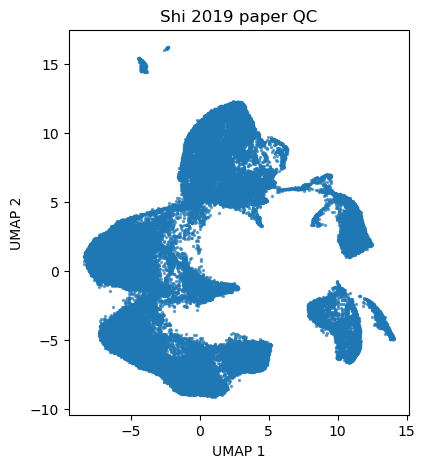

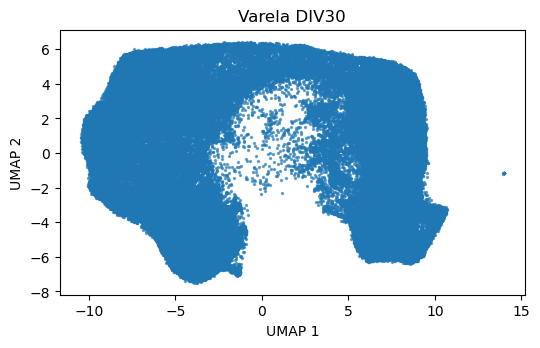

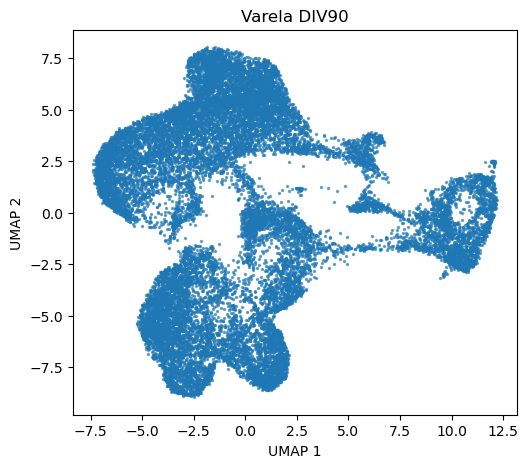

In [26]:
def plot_umap(adata, title, color_by=None, s=2, alpha=0.6):
    umap = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    if color_by and color_by in adata.obs:
        values = adata.obs[color_by].astype("category")
        codes = values.cat.codes
        scatter = ax.scatter(umap[:, 0], umap[:, 1], c=codes, s=s, alpha=alpha, cmap="tab20")
        ax.set_title(f"{title} colored by {color_by}")
    else:
        ax.scatter(umap[:, 0], umap[:, 1], s=s, alpha=alpha)
        ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    return fig, ax

plot_umap(adatas["shi_2019_paper_qc"], "Shi 2019 paper QC")
plot_umap(adatas["varela_div30"], "Varela DIV30")
plot_umap(adatas["varela_div90"], "Varela DIV90")
plt.show()

## Working With One Object

Use the `adatas` dictionary for downstream analysis. Keys are:

- `shi_2019_paper_qc`
- `varela_div30`
- `varela_div90`

In [27]:
adata = adatas["varela_div30"]
print(adata)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))

AnnData object with n_obs × n_vars = 90631 × 18082 backed at '/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad'
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters'
    var: 'feature_id'
    uns: 'conversion_manifest', 'seurat_assay', 'seurat_reduction', 'source_seurat_path'
    obsm: 'X_umap'
obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters']
var columns: ['feature_id']
